# Let's learn Lognormal statistics

## First set up a virtual environment

Some systems (linux, MacOS) use python so they will protect the native installation to make sure everythign keeps working.

It is highly recommended you create and use a python virtual environment (.venv) and instyall libraries etc into that.

1. Command+Shift+P: Python: create environment
2. 'Quick create' venv in project root
3. You can name it something specific if doing this on both windows and Mac (.venv_Win or .venv_Mac)

Once this is done, make sure you have Command+Shift+P "Python: Select Intepreter" and select the one you made for the sysytem you are one.

In [1]:
print("Hello world")

Hello world


## Next section

This is going to generate the 1000 point dataset we'll be using moving forward. I've set the seed so the *random* numbers are the same each time.

This is the POPULATION set. Think of it as the ACTUAL heights of 1000 people.

In [2]:
import numpy as np

seed = 42
n_population = 100
rng = np.random.default_rng(seed)

normal_mean = 3.0
normal_sd = 1.0
data = rng.normal(loc=normal_mean, scale=normal_sd, size=n_population)

lognormal_gm = 1.0
lognormal_gsd = 1.5
lognormal_mu = np.log(lognormal_gm)
lognormal_sigma = np.log(lognormal_gsd)
ldata = rng.lognormal(mean=lognormal_mu, sigma=lognormal_sigma, size=n_population)

print("Normal data:", data)
print("Lognormal data:", ldata) 


Normal data: [3.30471708 1.96001589 3.7504512  3.94056472 1.04896481 1.69782049
 3.1278404  2.68375741 2.98319884 2.14695607 3.87939797 3.77779194
 3.0660307  4.12724121 3.46750934 2.14070754 3.36875078 2.0411174
 3.8784503  2.95007409 2.81513764 2.31907046 4.22254134 2.84547052
 2.57167218 2.64786645 3.53230919 3.36544406 3.41273261 3.430821
 5.1416476  2.59358498 2.48775727 2.18622727 3.61597942 4.12897229
 2.88605254 2.15984352 2.17551878 3.65059279 3.74325417 3.54315427
 2.33449029 3.23216132 3.11668581 3.2186886  3.87142878 3.22359555
 3.67891356 3.06757907 3.2891194  3.63128823 1.54284418 2.68032878
 2.52962735 2.36112215 2.72485775 4.49494131 2.13416888 3.96827835
 1.31713023 2.66511497 3.16275307 3.58622233 3.71122658 3.79334724
 2.65127493 2.53764821 3.85797588 2.80869568 1.72431368 1.86671279
 2.08054771 3.49716074 3.14242574 3.69048535 2.57274735 3.15853969
 3.62559039 2.69065346 3.45677524 2.33807406 2.63694615 2.61826211
 1.80416035 3.48697248 2.53059766 3.01249412 3.48074

## It looks cooler if you plot it!

Python has a great chart library called matplotlib which we're going to use to make a histogram of this data.


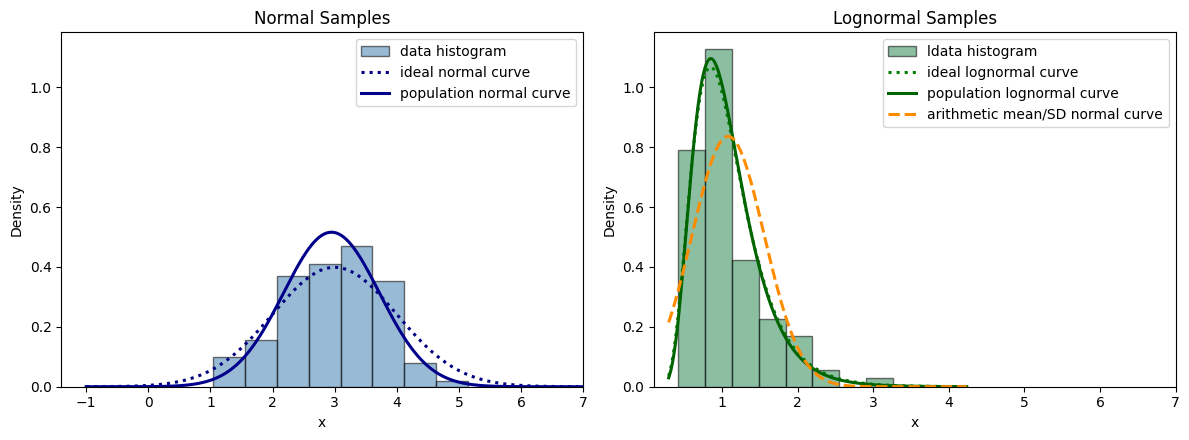

Normal population: mean=2.9497, SD=0.7728
Lognormal population: mean=1.0811, SD=0.4769, GM=0.9957, GSD=1.4846


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Alias to match requested variable name style.
lognormal_GSD = lognormal_gsd

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Normal dataset ---
# Ideal parameters (inputs)
normal_mean_ideal = normal_mean
normal_sd_ideal = normal_sd

# Population parameters (computed from actual data)
normal_mean_pop = np.mean(data)
normal_sd_pop = np.std(data, ddof=0)

x1_min = min(data.min(), normal_mean_ideal - 4 * normal_sd_ideal, normal_mean_pop - 4 * normal_sd_pop)
x1_max = max(data.max(), normal_mean_ideal + 4 * normal_sd_ideal, normal_mean_pop + 4 * normal_sd_pop)
x1 = np.linspace(x1_min, x1_max, 400)

normal_pdf_ideal = (1.0 / (normal_sd_ideal * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x1 - normal_mean_ideal) / normal_sd_ideal) ** 2)
normal_pdf_pop = (1.0 / (normal_sd_pop * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x1 - normal_mean_pop) / normal_sd_pop) ** 2)

axes[0].hist(data, bins=8, density=True, alpha=0.55, color='steelblue', edgecolor='black', label='data histogram')
axes[0].plot(x1, normal_pdf_ideal, color='navy', linestyle=':', linewidth=2.2, label='ideal normal curve')
axes[0].plot(x1, normal_pdf_pop, color='darkblue', linestyle='-', linewidth=2.2, label='population normal curve')
axes[0].set_title('Normal Samples')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()

# --- Lognormal dataset ---
# Ideal parameters (inputs)
lognormal_gm_ideal = lognormal_gm
lognormal_gsd_ideal = lognormal_GSD
lognormal_mu_ideal = np.log(lognormal_gm_ideal)
lognormal_sigma_ideal = np.log(lognormal_gsd_ideal)

# Population parameters (computed from actual data)
lognormal_mean_pop = np.mean(ldata)
lognormal_sd_pop = np.std(ldata, ddof=0)
lognormal_gm_pop = np.exp(np.mean(np.log(ldata)))
lognormal_gsd_pop = np.exp(np.std(np.log(ldata), ddof=0))
lognormal_mu_pop = np.log(lognormal_gm_pop)
lognormal_sigma_pop = np.log(lognormal_gsd_pop)

eps = 1e-12
lognormal_sd_pop = max(lognormal_sd_pop, eps)

x2_min = max(1e-6, ldata.min() * 0.7)
x2_max = ldata.max() * 1.3
x2 = np.linspace(x2_min, x2_max, 400)

lognormal_pdf_ideal = (1.0 / (x2 * lognormal_sigma_ideal * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((np.log(x2) - lognormal_mu_ideal) / lognormal_sigma_ideal) ** 2)
lognormal_pdf_pop = (1.0 / (x2 * lognormal_sigma_pop * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((np.log(x2) - lognormal_mu_pop) / lognormal_sigma_pop) ** 2)
lognormal_arithmetic_pdf_pop = (1.0 / (lognormal_sd_pop * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x2 - lognormal_mean_pop) / lognormal_sd_pop) ** 2)

axes[1].hist(ldata, bins=8, density=True, alpha=0.55, color='seagreen', edgecolor='black', label='ldata histogram')
axes[1].plot(x2, lognormal_pdf_ideal, color='green', linestyle=':', linewidth=2.2, label='ideal lognormal curve')
axes[1].plot(x2, lognormal_pdf_pop, color='darkgreen', linestyle='-', linewidth=2.2, label='population lognormal curve')
axes[1].plot(x2, lognormal_arithmetic_pdf_pop, color='darkorange', linestyle='--', linewidth=2.2, label='arithmetic mean/SD normal curve')
axes[1].set_title('Lognormal Samples')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].legend()

# Use the same vertical scale on both charts.
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, ymax)
axes[1].set_ylim(0, ymax)

# Use the same x-axis max on both charts.
xmax = max(x1_max, x2_max)
axes[0].set_xlim(axes[0].get_xlim()[0], xmax)
axes[1].set_xlim(axes[1].get_xlim()[0], xmax)

plt.tight_layout()
plt.show()

print(f"Normal population: mean={normal_mean_pop:.4f}, SD={normal_sd_pop:.4f}")
print(
    f"Lognormal population: mean={lognormal_mean_pop:.4f}, SD={lognormal_sd_pop:.4f}, "
    f"GM={lognormal_gm_pop:.4f}, GSD={lognormal_gsd_pop:.4f}"
)

## What does GSD represent?

For lognormal data, the **geometric mean (GM)** is the centre on the log scale and the **geometric standard deviation (GSD)** describes spread as a **multiplication factor**, not an addition/subtraction amount.

That means:

- one GSD band is from $GM / GSD$ to $GM \times GSD$
- two GSD bands are from $GM / GSD^2$ to $GM \times GSD^2$

For a perfect lognormal distribution, about 68% of values fall inside the one-GSD band and about 95% fall inside the two-GSD band.

In the next chart, `UCL95` is shown as the fitted one-sided 95th percentile of the lognormal distribution:

$$UCL95 = GM \times GSD^{1.645}$$

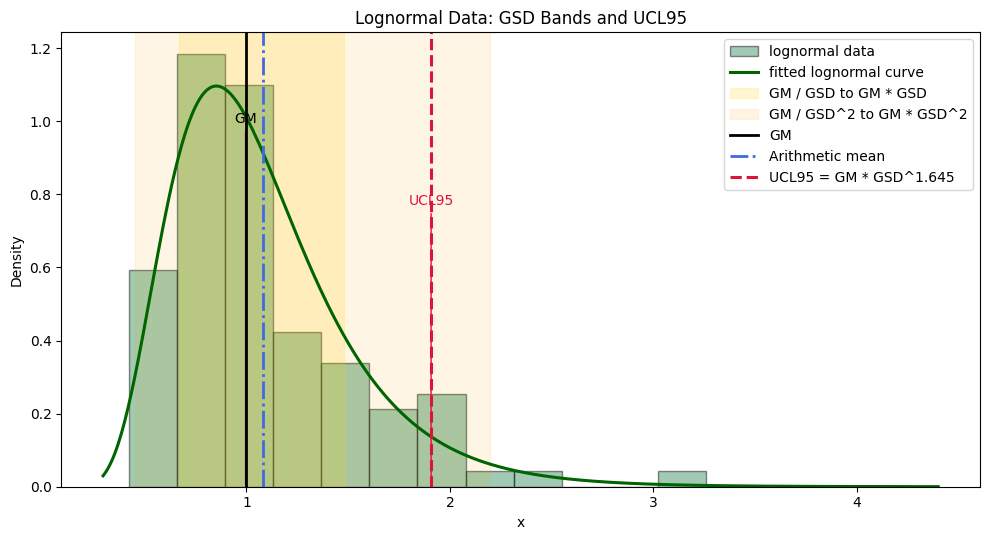

GM = 0.9957
GSD = 1.4846
Arithmetic mean = 1.0811
One-GSD band: 0.6707 to 1.4782
Two-GSD band: 0.4517 to 2.1947
UCL95 = 1.9074
Observed share inside one-GSD band = 66.0%
Observed share inside two-GSD band = 96.0%
Observed share below UCL95 = 93.0%


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstration parameters from the lognormal population
gm_demo = np.exp(np.mean(np.log(ldata)))
gsd_demo = np.exp(np.std(np.log(ldata), ddof=0))
mu_demo = np.log(gm_demo)
sigma_demo = np.log(gsd_demo)

arith_mean_demo = np.mean(ldata)
ucl95_demo = gm_demo * (gsd_demo ** 1.645)

one_gsd_low = gm_demo / gsd_demo
one_gsd_high = gm_demo * gsd_demo
two_gsd_low = gm_demo / (gsd_demo ** 2)
two_gsd_high = gm_demo * (gsd_demo ** 2)

share_in_1_gsd = np.mean((ldata >= one_gsd_low) & (ldata <= one_gsd_high))
share_in_2_gsd = np.mean((ldata >= two_gsd_low) & (ldata <= two_gsd_high))
share_below_ucl95 = np.mean(ldata <= ucl95_demo)

x_demo = np.linspace(max(1e-6, ldata.min() * 0.7), max(ldata.max() * 1.35, ucl95_demo * 1.1), 500)
lognormal_pdf_demo = (1.0 / (x_demo * sigma_demo * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((np.log(x_demo) - mu_demo) / sigma_demo) ** 2)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(ldata, bins=12, density=True, alpha=0.45, color='seagreen', edgecolor='black', label='lognormal data')
ax.plot(x_demo, lognormal_pdf_demo, color='darkgreen', linewidth=2.2, label='fitted lognormal curve')

ax.axvspan(one_gsd_low, one_gsd_high, color='gold', alpha=0.18, label='GM / GSD to GM * GSD')
ax.axvspan(two_gsd_low, two_gsd_high, color='orange', alpha=0.10, label='GM / GSD^2 to GM * GSD^2')

ax.axvline(gm_demo, color='black', linestyle='-', linewidth=2, label='GM')
ax.axvline(arith_mean_demo, color='royalblue', linestyle='-.', linewidth=2, label='Arithmetic mean')
ax.axvline(ucl95_demo, color='crimson', linestyle='--', linewidth=2.2, label='UCL95 = GM * GSD^1.645')

ax.annotate('GM', xy=(gm_demo, 0), xytext=(gm_demo, ax.get_ylim()[1] * 0.80), ha='center', color='black', arrowprops={'arrowstyle': '-','color': 'black'})
ax.annotate('UCL95', xy=(ucl95_demo, 0), xytext=(ucl95_demo, ax.get_ylim()[1] * 0.62), ha='center', color='crimson', arrowprops={'arrowstyle': '-','color': 'crimson'})

ax.set_title('Lognormal Data: GSD Bands and UCL95')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'GM = {gm_demo:.4f}')
print(f'GSD = {gsd_demo:.4f}')
print(f'Arithmetic mean = {arith_mean_demo:.4f}')
print(f'One-GSD band: {one_gsd_low:.4f} to {one_gsd_high:.4f}')
print(f'Two-GSD band: {two_gsd_low:.4f} to {two_gsd_high:.4f}')
print(f'UCL95 = {ucl95_demo:.4f}')
print(f'Observed share inside one-GSD band = {share_in_1_gsd:.1%}')
print(f'Observed share inside two-GSD band = {share_in_2_gsd:.1%}')
print(f'Observed share below UCL95 = {share_below_ucl95:.1%}')

It can be seen that with 1000 data points in the population, it approximates the input variables fairly well.

## Let grab a sample size (n=15) of the population

We collected 15 samples from each population and display THAT over the population curve.

NOTE: We choose (choice function) with replacement=True. I don't agree with it but that's the convention.

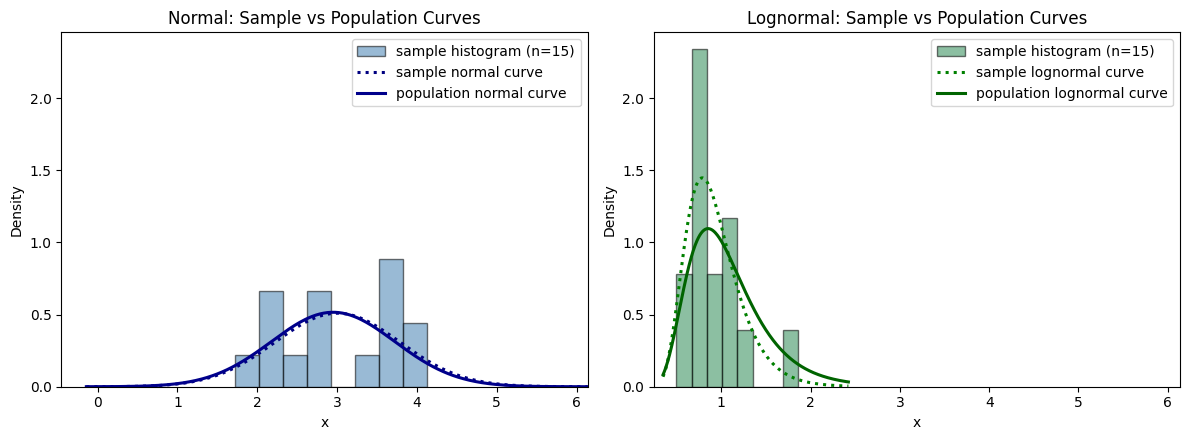

Normal sample: mean=3.0057, SD=0.7828
Normal population: mean=2.9497, SD=0.7728
Lognormal sample: GM=0.8781, GSD=1.3930
Lognormal population: GM=0.9957, GSD=1.4846


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Random sample settings
sample_seed = 2026
sample_size = 15
sample_rng = np.random.default_rng(sample_seed)

# Draw random samples from each population
sample_data = sample_rng.choice(data, size=sample_size, replace=True)
sample_ldata = sample_rng.choice(ldata, size=sample_size, replace=True)

# Population parameters (from full populations)
normal_mean_pop = np.mean(data)
normal_sd_pop = np.std(data, ddof=0)
lognormal_gm_pop = np.exp(np.mean(np.log(ldata)))
lognormal_gsd_pop = np.exp(np.std(np.log(ldata), ddof=0))

# Sample parameters (from 15-point samples)
normal_mean_sample = np.mean(sample_data)
normal_sd_sample = np.std(sample_data, ddof=1)
lognormal_gm_sample = np.exp(np.mean(np.log(sample_ldata)))
lognormal_gsd_sample = np.exp(np.std(np.log(sample_ldata), ddof=1))

# Avoid zero-width distributions in edge cases
eps = 1e-12
normal_sd_pop = max(normal_sd_pop, eps)
normal_sd_sample = max(normal_sd_sample, eps)
lognormal_sigma_pop = max(np.log(lognormal_gsd_pop), eps)
lognormal_sigma_sample = max(np.log(lognormal_gsd_sample), eps)
lognormal_mu_pop = np.log(lognormal_gm_pop)
lognormal_mu_sample = np.log(lognormal_gm_sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Normal sample histogram with sample and population curves
x1_min = min(sample_data.min(), normal_mean_pop - 4 * normal_sd_pop, normal_mean_sample - 4 * normal_sd_sample)
x1_max = max(sample_data.max(), normal_mean_pop + 4 * normal_sd_pop, normal_mean_sample + 4 * normal_sd_sample)
x1 = np.linspace(x1_min, x1_max, 400)

normal_pdf_pop = (1.0 / (normal_sd_pop * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x1 - normal_mean_pop) / normal_sd_pop) ** 2)
normal_pdf_sample = (1.0 / (normal_sd_sample * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x1 - normal_mean_sample) / normal_sd_sample) ** 2)

axes[0].hist(sample_data, bins=8, density=True, alpha=0.55, color='steelblue', edgecolor='black', label='sample histogram (n=15)')
axes[0].plot(x1, normal_pdf_sample, color='navy', linestyle=':', linewidth=2.2, label='sample normal curve')
axes[0].plot(x1, normal_pdf_pop, color='darkblue', linestyle='-', linewidth=2.2, label='population normal curve')
axes[0].set_title('Normal: Sample vs Population Curves')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()

# Lognormal sample histogram with sample and population curves
x2_min = max(1e-6, sample_ldata.min() * 0.7)
x2_max = sample_ldata.max() * 1.3
x2 = np.linspace(x2_min, x2_max, 400)

lognormal_pdf_pop = (1.0 / (x2 * lognormal_sigma_pop * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((np.log(x2) - lognormal_mu_pop) / lognormal_sigma_pop) ** 2)
lognormal_pdf_sample = (1.0 / (x2 * lognormal_sigma_sample * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((np.log(x2) - lognormal_mu_sample) / lognormal_sigma_sample) ** 2)

axes[1].hist(sample_ldata, bins=8, density=True, alpha=0.55, color='seagreen', edgecolor='black', label='sample histogram (n=15)')
axes[1].plot(x2, lognormal_pdf_sample, color='green', linestyle=':', linewidth=2.2, label='sample lognormal curve')
axes[1].plot(x2, lognormal_pdf_pop, color='darkgreen', linestyle='-', linewidth=2.2, label='population lognormal curve')
axes[1].set_title('Lognormal: Sample vs Population Curves')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].legend()

# Use the same vertical scale on both charts.
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, ymax)
axes[1].set_ylim(0, ymax)

# Use the same x-axis max on both charts.
xmax = max(x1_max, x2_max)
axes[0].set_xlim(axes[0].get_xlim()[0], xmax)
axes[1].set_xlim(axes[1].get_xlim()[0], xmax)

plt.tight_layout()
plt.show()

print(f"Normal sample: mean={normal_mean_sample:.4f}, SD={normal_sd_sample:.4f}")
print(f"Normal population: mean={normal_mean_pop:.4f}, SD={normal_sd_pop:.4f}")
print(f"Lognormal sample: GM={lognormal_gm_sample:.4f}, GSD={lognormal_gsd_sample:.4f}")
print(f"Lognormal population: GM={lognormal_gm_pop:.4f}, GSD={lognormal_gsd_pop:.4f}")

## Repeated sampling

This time lets keep the same population, let's also only sample 15 data points and calulcate the mean SD, GM and GSD but we'll call that trial 1.

For trial 2 we'll select ANOTHER random 15 data points from the population, calculate the mean etc.

Let's do this 10 times (10 trials) then look at the list og means, SD etc and then the mean of the means, the mean of the SD's etc.

Trials data.frame (normal_mean only):
    trial  sample_size  normal_mean
0       1           15     2.877679
1       2           15     2.883548
2       3           15     3.189779
3       4           15     2.738990
4       5           15     2.925593
..    ...          ...          ...
95     96           15     2.978824
96     97           15     3.200165
97     98           15     3.092178
98     99           15     2.618353
99    100           15     3.191523

[100 rows x 3 columns]

Mean of normal_mean over trials:
                  normal_mean
mean_over_trials     2.937814


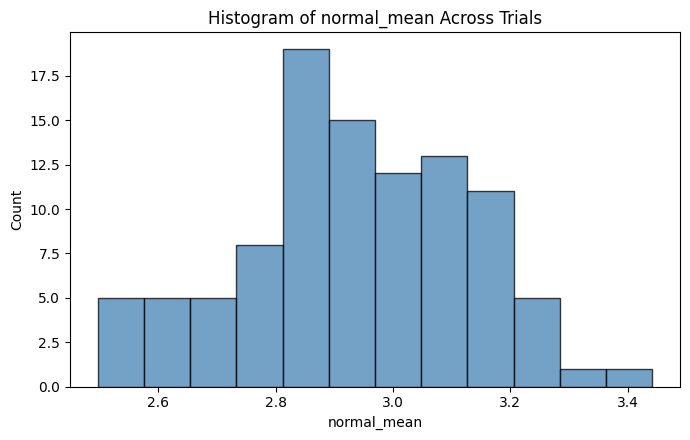

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Trial settings
n_trials = 100
sample_size = 15
trial_seed = 20260313
trial_rng = np.random.default_rng(trial_seed)

trial_rows = []

for trial in range(1, n_trials + 1):
    # Draw random samples without replacement from normal population
    sample_data = trial_rng.choice(data, size=sample_size, replace=True)

    # Keep only the sample mean for each trial
    normal_mean_sample = np.mean(sample_data)

    trial_rows.append(
        {
            "trial": trial,
            "sample_size": sample_size,
            "normal_mean": normal_mean_sample,
        }
    )

trials = pd.DataFrame(trial_rows)

print("Trials data.frame (normal_mean only):")
print(trials)

mean_stats = trials[["normal_mean"]].mean().to_frame(name="mean_over_trials").T
print("\nMean of normal_mean over trials:")
print(mean_stats)

plt.figure(figsize=(7, 4.5))
plt.hist(trials["normal_mean"], bins=12, color="steelblue", edgecolor="black", alpha=0.75)
plt.title("Histogram of normal_mean Across Trials")
plt.xlabel("normal_mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Great, the mean of the means looks like our population mean!

THAT is the **Central Limit Theory** in action!

## Can we do something similar with lognormal data

Lets try the same thing with lognormal data. This time we'll use:
- the mean of the geometric means.
- the geometric mean of the geometric means.

Trials data.frame (geometric_mean only):
    trial  sample_size  geometric_mean
0       1           15        1.052993
1       2           15        1.147398
2       3           15        0.907161
3       4           15        1.083747
4       5           15        1.000265
..    ...          ...             ...
95     96           15        1.215028
96     97           15        1.079926
97     98           15        1.027821
98     99           15        1.025532
99    100           15        1.140135

[100 rows x 3 columns]

Mean of geometric_mean over trials:
                  geometric_mean
mean_over_trials        1.005955

Trials data.frame (geometric_mean_of_geometric_means):
    trial  sample_size  geometric_mean_of_geometric_means
0       1           15                           1.042506
1       2           15                           1.036369
2       3           15                           0.990349
3       4           15                           1.033828
4       5         

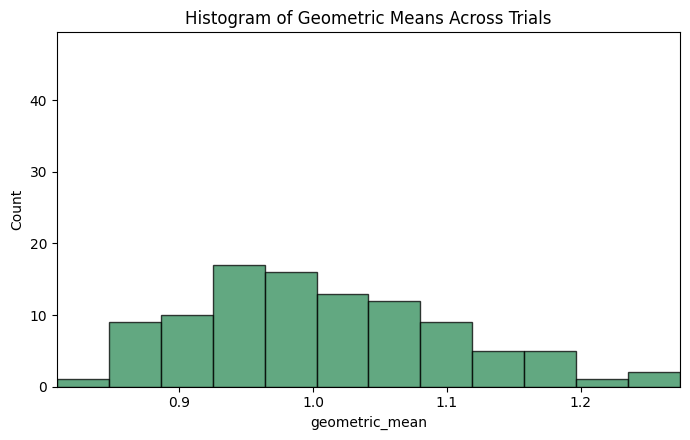

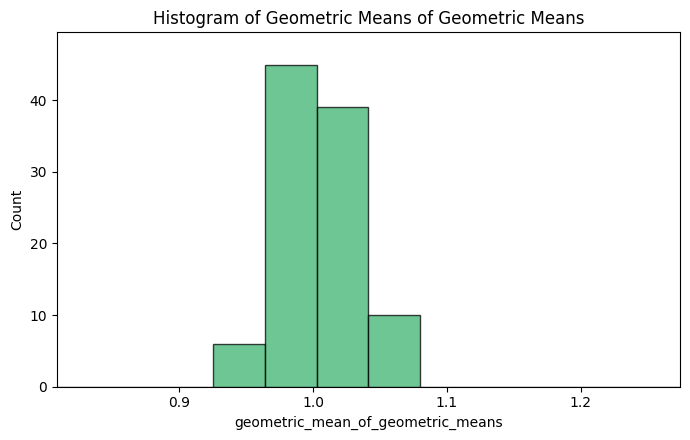

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Trial settings
n_trials = 100
sample_size = 15
trial_seed = 20260313
trial_rng = np.random.default_rng(trial_seed)

trial_rows = []

for trial in range(1, n_trials + 1):
    # Draw random samples with replacement from lognormal population
    sample_ldata = trial_rng.choice(ldata, size=sample_size, replace=True)

    # Geometric mean for each trial
    geometric_mean_sample = np.exp(np.mean(np.log(sample_ldata)))

    trial_rows.append(
        {
            "trial": trial,
            "sample_size": sample_size,
            "geometric_mean": geometric_mean_sample,
        }
    )

trials = pd.DataFrame(trial_rows)

print("Trials data.frame (geometric_mean only):")
print(trials)

mean_stats = trials[["geometric_mean"]].mean().to_frame(name="mean_over_trials").T
print("\nMean of geometric_mean over trials:")
print(mean_stats)

# Second-level sampling: geometric means of geometric means
gm_of_gm_trials = 100
gm_of_gm_sample_size = 15
gm_of_gm_rows = []

for trial in range(1, gm_of_gm_trials + 1):
    gm_sample = trial_rng.choice(trials["geometric_mean"].to_numpy(), size=gm_of_gm_sample_size, replace=True)
    gm_of_gm = np.exp(np.mean(np.log(gm_sample)))
    gm_of_gm_rows.append({"trial": trial, "sample_size": gm_of_gm_sample_size, "geometric_mean_of_geometric_means": gm_of_gm})

gm_of_gm_df = pd.DataFrame(gm_of_gm_rows)

print("\nTrials data.frame (geometric_mean_of_geometric_means):")
print(gm_of_gm_df)

gm_of_gm_mean = gm_of_gm_df[["geometric_mean_of_geometric_means"]].mean().to_frame(name="mean_over_trials").T
print("\nMean of geometric_mean_of_geometric_means over trials:")
print(gm_of_gm_mean)

# Shared axis scale for the last two histograms
n_bins = 12
combined_min = min(trials["geometric_mean"].min(), gm_of_gm_df["geometric_mean_of_geometric_means"].min())
combined_max = max(trials["geometric_mean"].max(), gm_of_gm_df["geometric_mean_of_geometric_means"].max())
shared_bin_edges = np.linspace(combined_min, combined_max, n_bins + 1)

counts_1, _ = np.histogram(trials["geometric_mean"], bins=shared_bin_edges)
counts_2, _ = np.histogram(gm_of_gm_df["geometric_mean_of_geometric_means"], bins=shared_bin_edges)
shared_ymax = 1.1 * max(counts_1.max(), counts_2.max())

plt.figure(figsize=(7, 4.5))
plt.hist(trials["geometric_mean"], bins=shared_bin_edges, color="seagreen", edgecolor="black", alpha=0.75)
plt.title("Histogram of Geometric Means Across Trials")
plt.xlabel("geometric_mean")
plt.ylabel("Count")
plt.xlim(combined_min, combined_max)
plt.ylim(0, shared_ymax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.hist(gm_of_gm_df["geometric_mean_of_geometric_means"], bins=shared_bin_edges, color="mediumseagreen", edgecolor="black", alpha=0.75)
plt.title("Histogram of Geometric Means of Geometric Means")
plt.xlabel("geometric_mean_of_geometric_means")
plt.ylabel("Count")
plt.xlim(combined_min, combined_max)
plt.ylim(0, shared_ymax)
plt.tight_layout()
plt.show()